# DBSCAN Anomaly

In [75]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

In [20]:
X,y = make_moons(
    n_samples=500,
    noise = 0.1,
    random_state=42
)

In [21]:
X.shape

(500, 2)

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

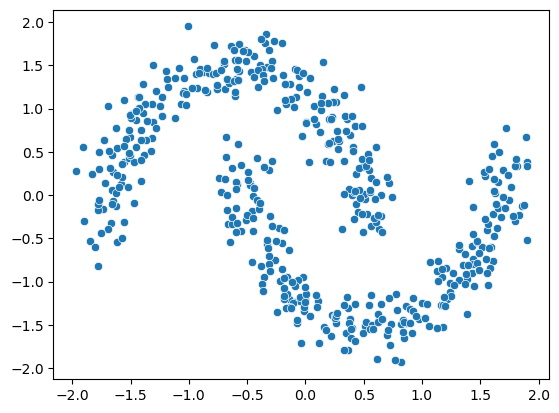

In [23]:
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1]
)

In [24]:
db = DBSCAN(
    eps=0.18,
    min_samples=5
)
label = db.fit_predict(X_scaled)

<Axes: >

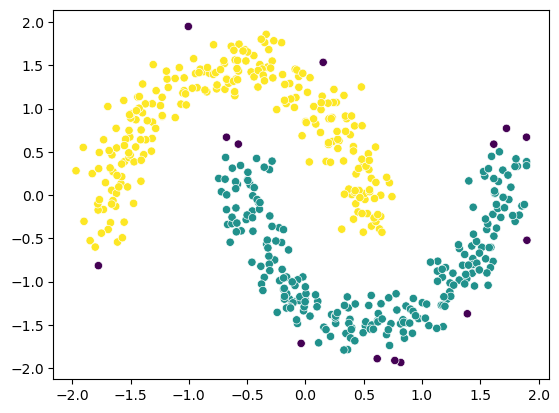

In [25]:
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    c=label
)

# ISOLATION Forest

In [26]:
data = pd.read_csv(
    "X:\\VScode\\Artificial_intelligence_n_Machine_learning\\Unsupervised_Learning\\thyroid_dataset.csv"
)
data.head(10)

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0000,23.00000,87.00,26.00000,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0000,61.00000,96.00,64.00000,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0000,58.00000,103.00,56.00000,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0000,24.00000,61.00,39.00000,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0000,5.00000,116.00,4.00000,o
5,0.85,0,0,0,0,0,0,0,0,1,...,0,0,0,0,197.0,0.0096,0.03121,102.00,0.03042,o
6,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,197.0,0.0096,14.00000,62.00,23.00000,o
7,0.49,1,0,0,0,0,0,0,0,0,...,0,0,0,0,96.0,4.0000,0.00290,0.12,0.00240,o
8,0.51,0,0,0,0,0,0,0,0,0,...,0,0,0,0,131.0,3.0000,0.00839,101.00,0.00829,o
9,0.72,0,1,0,0,0,0,0,0,0,...,0,0,0,0,85.0,6.0000,22.00000,111.00,0.02000,o


In [35]:
X = data.drop("Outlier_label",axis=1)
y = data["Outlier_label"]
print(f"X Shape: {X.shape}")

X Shape: (6916, 21)


In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
clf = IsolationForest(
    n_estimators=200,
    random_state=42,
    contamination=0.037
)

In [72]:
label = clf.fit_predict(X_scaled)
label

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [73]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC 2')

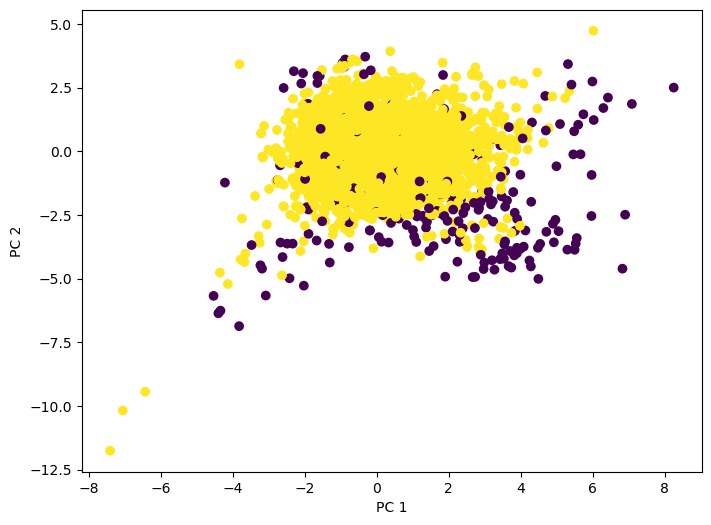

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=label  
)
plt.xlabel("PC 1")
plt.ylabel("PC 2")

In [70]:
n_outliers = np.sum(label == -1)
n_normal = np.sum(label == 1)

print(f"Number of Outlier: {n_outliers}")
print(f"Number of Normal: {n_normal}")

Number of Outlier: 249
Number of Normal: 6667


# LOF Anomaly

Text(0, 0.5, 'PC 2')

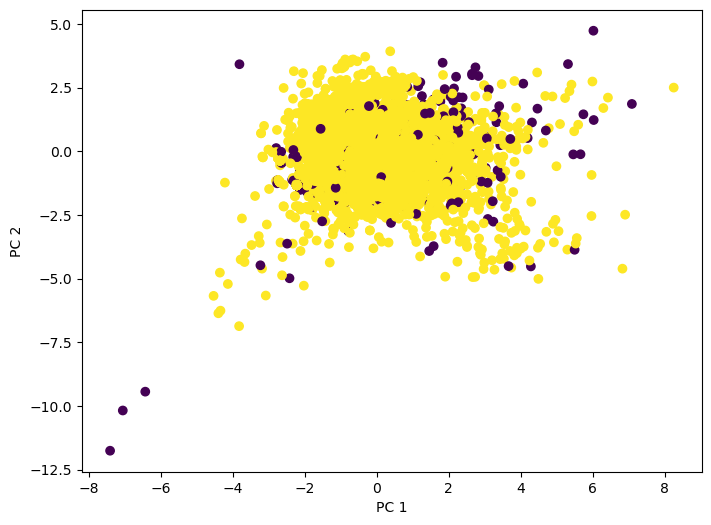

In [79]:
lof = LocalOutlierFactor(contamination=0.036)
label = lof.fit_predict(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=label  
)
plt.xlabel("PC 1")
plt.ylabel("PC 2")

In [80]:
n_outliers = np.sum(label == -1)
n_normal = np.sum(label == 1)

print(f"Number of Outlier: {n_outliers}")
print(f"Number of Normal: {n_normal}")

Number of Outlier: 249
Number of Normal: 6667
